In [6]:
import pandas as pd
import numpy as np
import os
import calendar
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import optuna
import torch
from optuna.trial import TrialState
from torch.utils.data import Dataset, DataLoader, TensorDataset,Subset
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = "plotly_white"
from sklearn.linear_model import LinearRegression
import seaborn as sns
plot_template = dict(
    layout=go.Layout({
        "font_size": 18,
        "xaxis_title_font_size": 24,
        "yaxis_title_font_size": 24})
)
import sys
sys.path.append('../..') # add parent path to sys.path
from OneShotSamplesGenerator import gen_one_out_samples
from Dataset import SimulatedSequenceDataset

from BiLSTMRegressor import BiLSTMRegressor,save_model,load_model
from BiLSTMRegressor import DEVICE
from BiLSTMRegressor import train_model
from BiLSTMRegressor import test_model
from BiLSTMRegressor import predict
from BiLSTMRegressor import plot_train_val_loss_cv
from BiLSTMRegressor import save_best_trial
from BiLSTMRegressor import load_best_trial
from BiLSTMRegressor import Objective_CV,Objective
from metrics import PPMAE,LPMAE
import HydroErr as he

class FliterMonthDataset(Dataset):
    def __init__(self, dataset:torch.utils.data.Dataset, index:pd.DatetimeIndex, months:list):
        self.dataset = dataset
        idx_list = []
        for idx,i_ in zip(index,range(self.dataset.y.shape[0])):
            if idx.month in months:
                idx_list.append(i_)
        
        self.subdataset = Subset(self.dataset, idx_list)
  
    def __len__(self):
        return len(self.subdataset)
    
    def __getitem__(self, i):
        X,y = self.subdataset[i]
        return X,y
hydro_stations = [
    'Guide',
    'Xunhua'
]
start_date = '1957-01-01'
end_date = '2019-12-31'

Build CER(BiLSTM) model and estimate natural flow during 1986-2019

In [7]:
for hydro_station in hydro_stations:
    print("-"*20,hydro_station,"-"*20)
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    df = df.loc[start_date:end_date]

    print(df)
    target = 'flow'
    features = list(df.columns.difference([target]))
    features = list(df.columns.copy())
    features.remove(target)
    print(features)

    cal = df.loc[:'1982-12-31',:]
    test = df.loc['1982-01-01':'1985-12-31',:]
    pre = df.loc['1985-01-01':,:]


    X_scaler = MinMaxScaler(feature_range=(0,1))
    Y_scaler = MinMaxScaler(feature_range=(0,1))
    X_scaler.fit(cal[features])
    Y_scaler.fit(cal[[target]])

    cal_X = X_scaler.transform(cal[features])
    test_X = X_scaler.transform(test[features])
    pre_X = X_scaler.transform(pre[features])

    cal_y = Y_scaler.transform(cal[[target]])
    test_y = Y_scaler.transform(test[[target]])
    pre_y = Y_scaler.transform(pre[[target]])

    cal = pd.concat([pd.DataFrame(cal_X,columns=features,index=cal.index),pd.DataFrame(cal_y,columns=[target],index=cal.index)],axis=1)
    test = pd.concat([pd.DataFrame(test_X,columns=features,index=test.index),pd.DataFrame(test_y,columns=[target],index=test.index)],axis=1)
    pre = pd.concat([pd.DataFrame(pre_X,columns=features,index=pre.index),pd.DataFrame(pre_y,columns=[target],index=pre.index)],axis=1)

    sequence_length =12
    cal_dataset = SimulatedSequenceDataset(
        dataframe=cal.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    test_dataset = SimulatedSequenceDataset(
        dataframe=test.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    pre_dataset = SimulatedSequenceDataset(
        dataframe=pre.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    full_dataset = SimulatedSequenceDataset(
        dataframe=df.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    # print(test_dataset.__len__())
    i=0
    X, y = cal_dataset[i]
    print(X)
    print(y)
    # print(cal_dataset.X)
    # print(cal_dataset.y)
    print(cal_dataset.X.shape, cal_dataset.y.shape)
    print(test_dataset.X.shape, test_dataset.y.shape)
    print(pre_dataset.X.shape, pre_dataset.y.shape)
    cal_index = cal.index[sequence_length:]
    test_index = test.index[sequence_length:]
    pre_index = pre.index[sequence_length:]
    full_index = df.index[sequence_length:]
    print(cal_index)
    # print(test_index)
    # print(pre_index)
    print(len(cal_index)==cal_dataset.__len__())
    print(len(test_index)==test_dataset.__len__())
    print(len(pre_index)==pre_dataset.__len__())
    print(len(full_index)==full_dataset.__len__())

    spring_dataset = FliterMonthDataset(dataset=cal_dataset, index=cal_index, months=[3,4,5])
    summer_dataset = FliterMonthDataset(dataset=cal_dataset, index=cal_index, months=[6, 7, 8])
    autumn_dataset = FliterMonthDataset(dataset=cal_dataset, index=cal_index, months=[9, 10, 11])
    winter_dataset = FliterMonthDataset(dataset=cal_dataset, index=cal_index, months=[12, 1, 2])
    spring_dataset

    model_path = f'../models/CER/{hydro_station.lower()}/BILSTM_lag12/'
    if not os.path.exists(model_path):
        os.makedirs(model_path)
    if not os.path.exists(model_path+'best_trial.pickle'):
        objective = Objective(
                train_dataset=cal_dataset,
                val_dataset=test_dataset,
                num_epoch=1000,
                batch_size=32,
                shuffle=True,
                model_path=model_path,
        )
        study = optuna.create_study(
                study_name='example-study',
                direction='minimize',
            )
        study.optimize(objective, n_trials=100)

        pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
        complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])


        print("Study statistics: ")
        print("  Number of finished trials: ", len(study.trials))
        print("  Number of pruned trials: ", len(pruned_trials))
        print("  Number of complete trials: ", len(complete_trials))

        print("Best trial:")
        trial = study.best_trial

        save_best_trial(trial, model_path=model_path)

        save_model(trial, model_path=model_path)

        best_model_state = trial.user_attrs["best_model_state"]


        print("  Value: ", trial.value)

        print("  Params: ")
        for key, value in trial.params.items():
            print("    {}: {}".format(key, value))

    ###########################
    best_trial = load_best_trial(model_file=model_path+'best_trial.pickle')
    model1 = load_model(model_file=model_path+'model.pickle').to(DEVICE)
    cal_loader = DataLoader(cal_dataset, batch_size=64, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    pre_loader = DataLoader(pre_dataset, batch_size=64, shuffle=False)
    ystar_col = "CER-BiLSTM"
    # print(cal)
    cal_ = cal.loc[cal_index,[target]].copy()
    test_ = test.loc[test_index,[target]].copy()
    pre_ = pre.loc[pre_index,[target]].copy()

    # get shape of cal_loader
    # for X, y in cal_loader:
    #     print(X.shape, y.shape)

    # print(cal_.shape, test_.shape, pre_.shape)

    cal_[ystar_col] = predict(cal_loader, model1).cpu().numpy()
    test_[ystar_col] = predict(test_loader, model1).cpu().numpy()
    pre_[ystar_col] = predict(pre_loader, model1).cpu().numpy()

    # Denormalize the predictions
    cal_[ystar_col] = Y_scaler.inverse_transform(cal_[[ystar_col]])
    test_[ystar_col] = Y_scaler.inverse_transform(test_[[ystar_col]])
    pre_[ystar_col] = Y_scaler.inverse_transform(pre_[[ystar_col]])

    # Denormalize the target values
    cal_[target] = Y_scaler.inverse_transform(cal_[[target]])
    test_[target] = Y_scaler.inverse_transform(test_[[target]])
    pre_[target] = Y_scaler.inverse_transform(pre_[[target]])

    metrics = pd.DataFrame(index=['cal','test'])
    metrics.index.name = 'period'

    metrics['ME'] = [he.me(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.me(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAE'] = [he.mae(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mae(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MSE'] = [he.mse(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MLE'] = [he.mle(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mle(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MALE'] = [he.male(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.male(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MSLE'] = [he.msle(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.msle(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAPE'] = [he.mape(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mape(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MDE'] = [he.mde(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mde(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MDAE'] = [he.mdae(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mdae(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MDSE'] = [he.mdse(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mdse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['ED'] = [he.ed(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.ed(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NED'] = [he.ned(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.ned(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['RMSE'] = [he.rmse(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.rmse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['RMSLE'] = [he.rmsle(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.rmsle(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NRMSE_RANGE'] = [he.nrmse_range(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nrmse_range(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NRMSE_MEAN'] = [he.nrmse_mean(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nrmse_mean(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NRMSE_IQR'] = [he.nrmse_iqr(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nrmse_iqr(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['IRMSE'] = [he.irmse(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.irmse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MASE'] = [he.mase(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.mase(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['R_SQUARED'] = [he.r_squared(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.r_squared(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['PEARSON_R'] = [he.pearson_r(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.pearson_r(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SPEARMAN_R'] = [he.spearman_r(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.spearman_r(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['ACC'] = [he.acc(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.acc(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAPE'] = [he.mape(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.mape(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAPD'] = [he.mapd(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.mapd(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAAPE'] = [he.maape(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.maape(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SMAPE1'] = [he.smape1(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.smape1(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SMAPE2'] = [he.smape2(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.smape2(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['D'] = [he.d(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.d(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['D1'] = [he.d1(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.d1(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['DMOD'] = [he.dmod(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.dmod(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['DREL'] = [he.drel(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.drel(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['DR'] = [he.dr(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.dr(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['WATT_M'] = [he.watt_m(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.watt_m(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MB_R'] = [he.mb_r(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.mb_r(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NSE'] = [he.nse(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NSE_MOD'] = [he.nse_mod(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nse_mod(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NSE_REL'] = [he.nse_rel(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nse_rel(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['KGE_2009'] = [he.kge_2009(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.kge_2009(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['KGE_2012'] = [he.kge_2012(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.kge_2012(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['LM_INDEX'] = [he.lm_index(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.lm_index(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['D1_P'] = [he.d1_p(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.d1_p(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['VE'] = [he.ve(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.ve(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SA'] = [he.sa(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.sa(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SC'] = [he.sc(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.sc(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SID'] = [he.sid(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.sid(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SGA'] = [he.sga(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.sga(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H1_MHE'] = [he.h1_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h1_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H1_MAHE'] = [he.h1_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h1_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H1_RMSHE'] = [he.h1_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h1_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H2_MHE'] = [he.h2_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h2_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H2_MAHE'] = [he.h2_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h2_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H2_RMSHE'] = [he.h2_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h2_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H3_MHE'] = [he.h3_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h3_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H3_MAHE'] = [he.h3_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h3_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H3_RMSHE'] = [he.h3_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h3_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H4_MHE'] = [he.h4_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h4_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H4_MAHE'] = [he.h4_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h4_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H4_RMSHE'] = [he.h4_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h4_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H5_MHE'] = [he.h5_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h5_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H5_MAHE'] = [he.h5_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h5_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H5_RMSHE'] = [he.h5_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h5_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H6_MHE'] = [he.h6_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h6_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H6_MAHE'] = [he.h6_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h6_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H6_RMSHE'] = [he.h6_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h6_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H7_MHE'] = [he.h7_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h7_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H7_MAHE'] = [he.h7_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h7_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H7_RMSHE'] = [he.h7_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h7_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H8_MHE'] = [he.h8_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h8_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H8_MAHE'] = [he.h8_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h8_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H8_RMSHE'] = [he.h8_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h8_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H10_MHE'] = [he.h10_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h10_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H10_MAHE'] = [he.h10_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h10_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H10_RMSHE'] = [he.h10_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h10_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['G_MEAN_DIFF'] = [he.g_mean_diff(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.g_mean_diff(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MEAN_VAR'] = [he.mean_var(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mean_var(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['PPMAE'] = [PPMAE(y_true=cal_[target],y_pred=cal_[ystar_col]),PPMAE(y_true=test_[target],y_pred=test_[ystar_col]),]
    metrics['LPMAE'] = [LPMAE(y_true=cal_[target],y_pred=cal_[ystar_col]),LPMAE(y_true=test_[target],y_pred=test_[ystar_col]),]
    

    df_out = pd.concat((cal_, test_, pre_))[[target, ystar_col]]
    # for c in df_out.columns:
    #     # df_out[c] = df_out[c] * target_std + target_mean
    #     df_out[c] = Y_scaler.inverse_transform(df_out[[c]])

    print(df_out)
    df_out.to_csv(f'../results/vif_bilstm_{hydro_station.lower()}.csv')

    metrics.to_csv(f'../results/vif_bilstm_metrics_{hydro_station.lower()}.csv')

    metrics

-------------------- Guide --------------------
                 v10  AVG-TEM(C)      smlt       sro        sd      ssro  \
date                                                                       
1960-01-31  0.937511  -12.752986  0.000423  0.000062  0.020468  0.004090   
1960-02-29  0.527554   -8.002374  0.003312  0.000932  0.020473  0.003107   
1960-03-31  0.934352   -2.523280  0.010951  0.002701  0.019050  0.002482   
1960-04-30  0.094989    0.700331  0.020436  0.004004  0.015169  0.002131   
1960-05-31 -0.060234    6.175353  0.028711  0.005169  0.004706  0.001985   
...              ...         ...       ...       ...       ...       ...   
2019-08-31 -0.321948   11.461266  0.003087  0.003291  0.000122  0.014945   
2019-09-30 -0.219753    7.523939  0.021006  0.003460  0.002640  0.019583   
2019-10-31  0.254881    2.215784  0.013888  0.000760  0.006718  0.020596   
2019-11-30  0.746981   -3.226049  0.009707  0.000264  0.015395  0.014721   
2019-12-31  0.760826  -12.046475  0.0011

Interprete CER(BiLSTM) model

-------------------- Guide --------------------
Guide


C:\Users\ZJY\AppData\Local\Temp\ipykernel_198176\4054472580.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(features,fontsize=8,rotation=45)
C:\Users\ZJY\AppData\Local\Temp\ipykernel_198176\4054472580.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticks(), fontsize=8)


[-1.3499025e+00  1.2818761e+00  2.0269948e-01  1.8750589e-02
  7.5156569e-02  1.5296477e-01  4.5661366e+01]


C:\Users\ZJY\AppData\Local\Temp\ipykernel_198176\4054472580.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Attribution Values', y='Features', data=df, orient='h', palette='viridis',width=0.9,ax=ax2)
C:\Users\ZJY\AppData\Local\Temp\ipykernel_198176\4054472580.py:157: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticks(), fontsize=8)


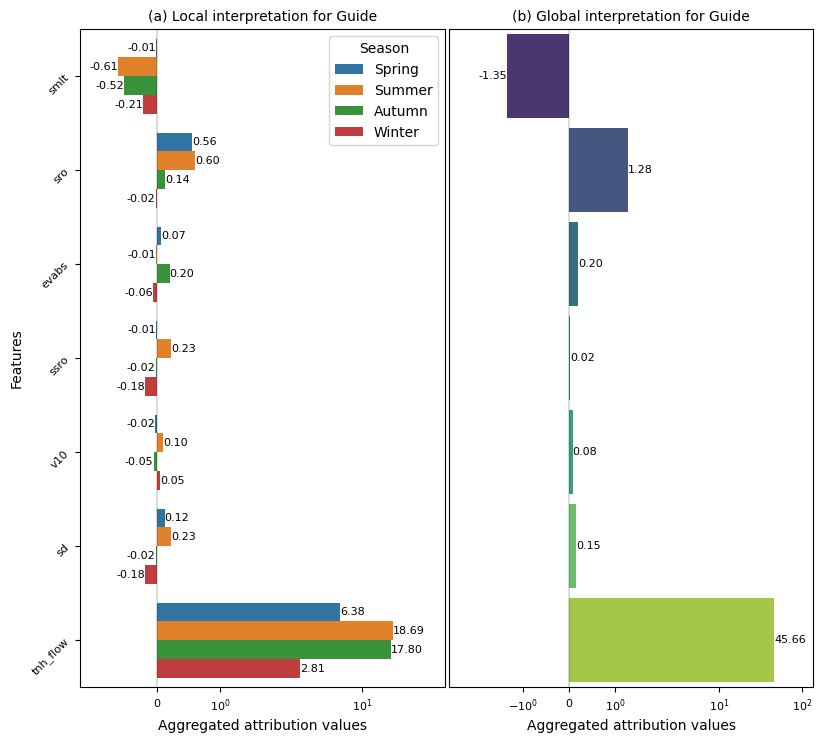

-------------------- Xunhua --------------------
Xunhua


C:\Users\ZJY\AppData\Local\Temp\ipykernel_198176\4054472580.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(features,fontsize=8,rotation=45)
C:\Users\ZJY\AppData\Local\Temp\ipykernel_198176\4054472580.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticks(), fontsize=8)


[ -0.6543305    0.57971907 -10.73688      3.5899763   -1.8909351
   0.1415145   44.349384  ]


C:\Users\ZJY\AppData\Local\Temp\ipykernel_198176\4054472580.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Attribution Values', y='Features', data=df, orient='h', palette='viridis',width=0.9,ax=ax2)
C:\Users\ZJY\AppData\Local\Temp\ipykernel_198176\4054472580.py:157: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticks(), fontsize=8)


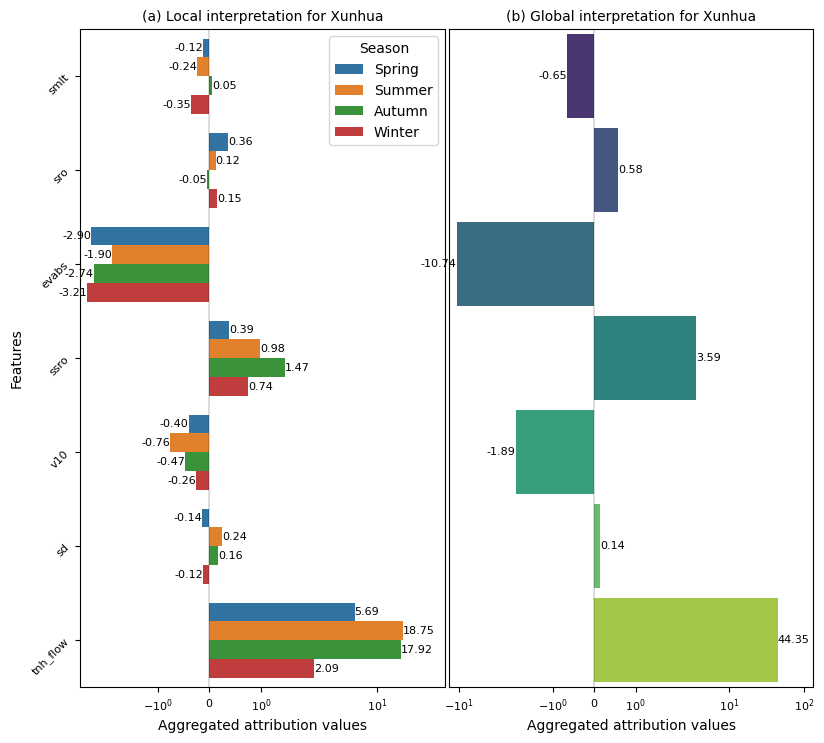

In [8]:
for hydro_station in hydro_stations:
    print("-"*20,hydro_station,"-"*20)
    print(hydro_station)

    model_path = f'../models/CER/{hydro_station.lower()}/BILSTM_lag12/'
    best_trial = load_best_trial(model_file=model_path+'best_trial.pickle')
    model1 = load_model(model_file=model_path+'model.pickle').to(DEVICE)

    ig = IntegratedGradients(model1)

    # features_ = []
    # for name in features:
    #     if '_' in name:
    #         name = name.split('_')[0]+'_{'+name.split('_')[1]+'}'
    #     features_.append('$'+name+'$')

    spring_loader = DataLoader(spring_dataset,batch_size=spring_dataset.__len__(),shuffle=False)
    summer_loader = DataLoader(summer_dataset,batch_size=summer_dataset.__len__(),shuffle=False)
    autumn_loader = DataLoader(autumn_dataset,batch_size=autumn_dataset.__len__(),shuffle=False)
    winter_loader = DataLoader(winter_dataset,batch_size=winter_dataset.__len__(),shuffle=False)

    aggregated_attributions_spring = []
    aggregated_attributions_summer = []
    aggregated_attributions_autumn = []
    aggregated_attributions_winter = []

    # Iterate over the test dataloader batches
    for inputs, labels in spring_loader:
        # Generate attributions using Integrated Gradients
        attributions_spring = ig.attribute(inputs.to(DEVICE))
        aggregated_attributions_spring.append(attributions_spring.cpu())
    for inputs, labels in summer_loader:
        # Generate attributions using Integrated Gradients
        attributions_summer = ig.attribute(inputs.to(DEVICE))
        aggregated_attributions_summer.append(attributions_summer.cpu())
    for inputs, labels in autumn_loader:
        # Generate attributions using Integrated Gradients
        attributions_autumn = ig.attribute(inputs.to(DEVICE))
        aggregated_attributions_autumn.append(attributions_autumn.cpu())
    for inputs, labels in winter_loader:
        # Generate attributions using Integrated Gradients
        attributions_winter = ig.attribute(inputs.to(DEVICE))
        aggregated_attributions_winter.append(attributions_winter.cpu())

    attributions_spring_sum = attributions_spring.sum(dim=0) # (13,8)
    attributions_spring_sum = np.array(attributions_spring_sum.sum(dim=0).cpu()) # (8)

    attributions_summer_sum = attributions_summer.sum(dim=0)
    attributions_summer_sum = np.array(attributions_summer_sum.sum(dim=0).cpu())

    attributions_autumn_sum = attributions_autumn.sum(dim=0)
    attributions_autumn_sum = np.array(attributions_autumn_sum.sum(dim=0).cpu())

    attributions_winter_sum = attributions_winter.sum(dim=0)
    attributions_winter_sum = np.array(attributions_winter_sum.sum(dim=0).cpu())

    df = pd.DataFrame({
        'Spring':attributions_spring_sum,
        'Summer':attributions_summer_sum,
        'Autumn':attributions_autumn_sum,
        'Winter':attributions_winter_sum,
    },index=features)

    df = df.reset_index().melt(id_vars='index', var_name='Season', value_name='Contribution')

    # 使用seaborn的barplot函数绘制柱状图
    ftsize=10
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(7.48, 7))
    ax1 = sns.barplot(x='Contribution', y='index', hue='Season', data=df, orient='h',ax=ax1)
    # 在柱状图的柱子上显示数值
    # 在柱状图的柱子上显示数值和短线
    for p in ax1.patches:
        width = p.get_width()    # 获取柱子的宽度
        if abs(width) < 0.001:  # 如果值接近0，跳过
            continue
        if abs(width) < 0.1:  # 如果值接近0，设置一个较小的偏移量
            offset = 0.02
        else:  # 如果值较大，设置一个较大的偏移量
            offset = 0.2
        if width >=0:    # 如果宽度为正（即值为正）
            ax1.text(width ,       # 在柱子右边端点以外
                    p.get_y() + p.get_height() / 2,  # y坐标（柱子的中心）
                    '{:1.2f}'.format(width),   # 要显示的文本（柱子的宽度，保留两位小数）
                    ha = 'left',   # 水平对齐方式
                    va = 'center',
                    fontsize=8)  # 垂直对齐方式
        else:    # 如果宽度为负（即值为负）
            ax1.text(width ,       # 在柱子左边端点以外
                    p.get_y() + p.get_height() / 2,  # y坐标（柱子的中心）
                    '{:1.2f}'.format(width),   # 要显示的文本（柱子的宽度，保留两位小数）
                    ha = 'right',   # 水平对齐方式
                    va = 'center',
                    fontsize=8)  # 垂直对齐方式
    ax1.set_xlim(df['Contribution'].min()-0.6, df['Contribution'].max()+35)
    ax1.axvline(x=0.0, color='black', linestyle='-', linewidth=0.2)
    ax1.set_ylabel('Features',fontsize=ftsize)
    ax1.set_yticklabels(features,fontsize=8,rotation=45)
    ax1.set_xlabel('Aggregated attribution values',fontsize=ftsize)
    ax1.set_xticklabels(ax1.get_xticks(), fontsize=8)
    ax1.set_xscale('symlog')
    ax1.set_title('(a) Local interpretation for {}'.format(hydro_station.capitalize()),fontsize=ftsize)

    cal_dataloader = DataLoader(cal_dataset)
    aggregated_attributions = []
    # Iterate over the test dataloader batches
    for inputs, labels in cal_dataloader:
        # Generate attributions using Integrated Gradients
        attributions = ig.attribute(inputs.to(DEVICE))
        aggregated_attributions.append(attributions.cpu())
    # Concatenate the attributions along the batch dimension
    aggregated_attributions = torch.cat(aggregated_attributions, dim=0)

    # Convert the aggregated_attributions tensor to a numpy array
    attributions_np = aggregated_attributions.detach().numpy()

    # Calculate the mean attributions across all samples
    sum_attributions = np.sum(attributions_np, axis=0)
    sum_attributions = np.sum(sum_attributions, axis=0)
    print(sum_attributions)

    df = pd.DataFrame({
        'Features': features,
        'Attribution Values': sum_attributions
    })
    # Plot the attributions for each feature
    x_pos = (np.arange(len(features)))
    ax2 = sns.barplot(x='Attribution Values', y='Features', data=df, orient='h', palette='viridis',width=0.9,ax=ax2)
    # Add numbers on each bar
    for p in ax2.patches:    
        width = p.get_width()    # 获取柱子的宽度
        if abs(width) < 0.001:  # 如果值接近0，跳过
            continue
        if abs(width) < 0.1:  # 如果值接近0，设置一个较小的偏移量
            offset = 0.02
        else:  # 如果值较大，设置一个较大的偏移量
            offset = 0.2
        if width >=0:    # 如果宽度为正（即值为正）
            ax2.text(width ,       # 在柱子右边端点以外
                    p.get_y() + p.get_height() / 2,  # y坐标（柱子的中心）
                    '{:1.2f}'.format(width),   # 要显示的文本（柱子的宽度，保留两位小数）
                    ha = 'left',   # 水平对齐方式
                    va = 'center',
                    fontsize=8)  # 垂直对齐方式
        else:    # 如果宽度为负（即值为负）
            ax2.text(width ,       # 在柱子左边端点以外
                    p.get_y() + p.get_height() / 2,  # y坐标（柱子的中心）
                    '{:1.2f}'.format(width),   # 要显示的文本（柱子的宽度，保留两位小数）
                    ha = 'right',   # 水平对齐方式
                    va = 'center',
                    fontsize=8)  # 垂直对齐方式
    ax2.set_xlim(df['Attribution Values'].min()-3.0, df['Attribution Values'].max()+90)
    ax2.axvline(x=0.0, color='black', linestyle='-', linewidth=0.2)
    ax2.set_yticklabels([])
    ax2.yaxis.set_ticks([])
    ax2.set_ylabel('')
    ax2.set_xlabel('Aggregated attribution values',fontsize=ftsize)
    ax2.set_xticklabels(ax2.get_xticks(), fontsize=8)
    ax2.set_xscale('symlog')
    ax2.set_title('(b) Global interpretation for {}'.format(hydro_station.capitalize()),fontsize=ftsize)
    fig.subplots_adjust(left=0.01, bottom=0.05, right=0.99,top=0.99, hspace=0.05, wspace=0.01)
    plt.savefig(f'../figs/{hydro_station.lower()}_features_contributions_IG_BILSTM.tif',format='TIFF',dpi=500,transparent=False,bbox_inches='tight')
    plt.show()

Build Extension(BiLSTM) model and estimate natural flow during 1986-2019

In [9]:
for hydro_station in hydro_stations:
    print("-"*20,hydro_station,"-"*20)
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    df = df.loc[start_date:end_date]
    # drop tnh_flow
    df = df.drop(columns=['tnh_flow'])

    print(df)
    target = 'flow'
    features = list(df.columns.difference([target]))
    features = list(df.columns.copy())
    features.remove(target)
    print(features)

    cal = df.loc[:'1982-12-31',:]
    test = df.loc['1982-01-01':'1985-12-31',:]
    pre = df.loc['1985-01-01':,:]


    X_scaler = MinMaxScaler(feature_range=(0,1))
    Y_scaler = MinMaxScaler(feature_range=(0,1))
    X_scaler.fit(cal[features])
    Y_scaler.fit(cal[[target]])

    cal_X = X_scaler.transform(cal[features])
    test_X = X_scaler.transform(test[features])
    pre_X = X_scaler.transform(pre[features])

    cal_y = Y_scaler.transform(cal[[target]])
    test_y = Y_scaler.transform(test[[target]])
    pre_y = Y_scaler.transform(pre[[target]])

    cal = pd.concat([pd.DataFrame(cal_X,columns=features,index=cal.index),pd.DataFrame(cal_y,columns=[target],index=cal.index)],axis=1)
    test = pd.concat([pd.DataFrame(test_X,columns=features,index=test.index),pd.DataFrame(test_y,columns=[target],index=test.index)],axis=1)
    pre = pd.concat([pd.DataFrame(pre_X,columns=features,index=pre.index),pd.DataFrame(pre_y,columns=[target],index=pre.index)],axis=1)

    sequence_length =12
    cal_dataset = SimulatedSequenceDataset(
        dataframe=cal.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    test_dataset = SimulatedSequenceDataset(
        dataframe=test.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    pre_dataset = SimulatedSequenceDataset(
        dataframe=pre.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    full_dataset = SimulatedSequenceDataset(
        dataframe=df.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    # print(test_dataset.__len__())
    i=0
    X, y = cal_dataset[i]
    print(X)
    print(y)
    # print(cal_dataset.X)
    # print(cal_dataset.y)
    print(cal_dataset.X.shape, cal_dataset.y.shape)
    print(test_dataset.X.shape, test_dataset.y.shape)
    print(pre_dataset.X.shape, pre_dataset.y.shape)
    cal_index = cal.index[sequence_length:]
    test_index = test.index[sequence_length:]
    pre_index = pre.index[sequence_length:]
    full_index = df.index[sequence_length:]
    print(cal_index)
    # print(test_index)
    # print(pre_index)
    print(len(cal_index)==cal_dataset.__len__())
    print(len(test_index)==test_dataset.__len__())
    print(len(pre_index)==pre_dataset.__len__())
    print(len(full_index)==full_dataset.__len__())

    spring_dataset = FliterMonthDataset(dataset=cal_dataset, index=cal_index, months=[3,4,5])
    summer_dataset = FliterMonthDataset(dataset=cal_dataset, index=cal_index, months=[6, 7, 8])
    autumn_dataset = FliterMonthDataset(dataset=cal_dataset, index=cal_index, months=[9, 10, 11])
    winter_dataset = FliterMonthDataset(dataset=cal_dataset, index=cal_index, months=[12, 1, 2])
    spring_dataset

    model_path = f'../models/Extension/{hydro_station.lower()}/BILSTM_lag12/'
    if not os.path.exists(model_path):
        os.makedirs(model_path)
    if not os.path.exists(model_path+'best_trial.pickle'):
        objective = Objective(
                train_dataset=cal_dataset,
                val_dataset=test_dataset,
                num_epoch=1000,
                batch_size=32,
                shuffle=True,
                model_path=model_path,
        )
        study = optuna.create_study(
                study_name='example-study',
                direction='minimize',
            )
        study.optimize(objective, n_trials=100)

        pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
        complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])


        print("Study statistics: ")
        print("  Number of finished trials: ", len(study.trials))
        print("  Number of pruned trials: ", len(pruned_trials))
        print("  Number of complete trials: ", len(complete_trials))

        print("Best trial:")
        trial = study.best_trial

        save_best_trial(trial, model_path=model_path)

        save_model(trial, model_path=model_path)

        best_model_state = trial.user_attrs["best_model_state"]


        print("  Value: ", trial.value)

        print("  Params: ")
        for key, value in trial.params.items():
            print("    {}: {}".format(key, value))

    ###########################
    best_trial = load_best_trial(model_file=model_path+'best_trial.pickle')
    model1 = load_model(model_file=model_path+'model.pickle').to(DEVICE)
    cal_loader = DataLoader(cal_dataset, batch_size=64, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    pre_loader = DataLoader(pre_dataset, batch_size=64, shuffle=False)
    ystar_col = "E-BiLSTM"
    # print(cal)
    cal_ = cal.loc[cal_index,[target]].copy()
    test_ = test.loc[test_index,[target]].copy()
    pre_ = pre.loc[pre_index,[target]].copy()

    # get shape of cal_loader
    # for X, y in cal_loader:
    #     print(X.shape, y.shape)

    # print(cal_.shape, test_.shape, pre_.shape)

    cal_[ystar_col] = predict(cal_loader, model1).cpu().numpy()
    test_[ystar_col] = predict(test_loader, model1).cpu().numpy()
    pre_[ystar_col] = predict(pre_loader, model1).cpu().numpy()

    # Denormalize the predictions
    cal_[ystar_col] = Y_scaler.inverse_transform(cal_[[ystar_col]])
    test_[ystar_col] = Y_scaler.inverse_transform(test_[[ystar_col]])
    pre_[ystar_col] = Y_scaler.inverse_transform(pre_[[ystar_col]])

    # Denormalize the target values
    cal_[target] = Y_scaler.inverse_transform(cal_[[target]])
    test_[target] = Y_scaler.inverse_transform(test_[[target]])
    pre_[target] = Y_scaler.inverse_transform(pre_[[target]])

    metrics = pd.DataFrame(index=['cal','test'])
    metrics.index.name = 'period'

    metrics['ME'] = [he.me(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.me(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAE'] = [he.mae(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mae(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MSE'] = [he.mse(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MLE'] = [he.mle(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mle(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MALE'] = [he.male(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.male(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MSLE'] = [he.msle(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.msle(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAPE'] = [he.mape(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mape(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MDE'] = [he.mde(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mde(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MDAE'] = [he.mdae(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mdae(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MDSE'] = [he.mdse(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mdse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['ED'] = [he.ed(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.ed(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NED'] = [he.ned(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.ned(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['RMSE'] = [he.rmse(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.rmse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['RMSLE'] = [he.rmsle(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.rmsle(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NRMSE_RANGE'] = [he.nrmse_range(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nrmse_range(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NRMSE_MEAN'] = [he.nrmse_mean(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nrmse_mean(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NRMSE_IQR'] = [he.nrmse_iqr(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nrmse_iqr(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['IRMSE'] = [he.irmse(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.irmse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MASE'] = [he.mase(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.mase(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['R_SQUARED'] = [he.r_squared(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.r_squared(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['PEARSON_R'] = [he.pearson_r(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.pearson_r(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SPEARMAN_R'] = [he.spearman_r(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.spearman_r(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['ACC'] = [he.acc(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.acc(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAPE'] = [he.mape(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.mape(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAPD'] = [he.mapd(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.mapd(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAAPE'] = [he.maape(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.maape(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SMAPE1'] = [he.smape1(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.smape1(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SMAPE2'] = [he.smape2(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.smape2(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['D'] = [he.d(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.d(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['D1'] = [he.d1(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.d1(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['DMOD'] = [he.dmod(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.dmod(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['DREL'] = [he.drel(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.drel(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['DR'] = [he.dr(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.dr(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['WATT_M'] = [he.watt_m(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.watt_m(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MB_R'] = [he.mb_r(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.mb_r(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NSE'] = [he.nse(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NSE_MOD'] = [he.nse_mod(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nse_mod(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NSE_REL'] = [he.nse_rel(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nse_rel(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['KGE_2009'] = [he.kge_2009(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.kge_2009(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['KGE_2012'] = [he.kge_2012(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.kge_2012(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['LM_INDEX'] = [he.lm_index(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.lm_index(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['D1_P'] = [he.d1_p(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.d1_p(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['VE'] = [he.ve(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.ve(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SA'] = [he.sa(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.sa(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SC'] = [he.sc(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.sc(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SID'] = [he.sid(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.sid(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SGA'] = [he.sga(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.sga(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H1_MHE'] = [he.h1_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h1_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H1_MAHE'] = [he.h1_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h1_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H1_RMSHE'] = [he.h1_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h1_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H2_MHE'] = [he.h2_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h2_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H2_MAHE'] = [he.h2_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h2_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H2_RMSHE'] = [he.h2_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h2_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H3_MHE'] = [he.h3_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h3_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H3_MAHE'] = [he.h3_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h3_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H3_RMSHE'] = [he.h3_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h3_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H4_MHE'] = [he.h4_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h4_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H4_MAHE'] = [he.h4_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h4_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H4_RMSHE'] = [he.h4_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h4_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H5_MHE'] = [he.h5_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h5_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H5_MAHE'] = [he.h5_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h5_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H5_RMSHE'] = [he.h5_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h5_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H6_MHE'] = [he.h6_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h6_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H6_MAHE'] = [he.h6_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h6_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H6_RMSHE'] = [he.h6_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h6_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H7_MHE'] = [he.h7_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h7_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H7_MAHE'] = [he.h7_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h7_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H7_RMSHE'] = [he.h7_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h7_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H8_MHE'] = [he.h8_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h8_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H8_MAHE'] = [he.h8_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h8_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H8_RMSHE'] = [he.h8_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h8_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H10_MHE'] = [he.h10_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h10_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H10_MAHE'] = [he.h10_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h10_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H10_RMSHE'] = [he.h10_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h10_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['G_MEAN_DIFF'] = [he.g_mean_diff(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.g_mean_diff(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MEAN_VAR'] = [he.mean_var(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mean_var(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['PPMAE'] = [PPMAE(y_true=cal_[target],y_pred=cal_[ystar_col]),PPMAE(y_true=test_[target],y_pred=test_[ystar_col]),]
    metrics['LPMAE'] = [LPMAE(y_true=cal_[target],y_pred=cal_[ystar_col]),LPMAE(y_true=test_[target],y_pred=test_[ystar_col]),]

    df_out = pd.concat((cal_, test_, pre_))[[target, ystar_col]]
    # for c in df_out.columns:
    #     # df_out[c] = df_out[c] * target_std + target_mean
    #     df_out[c] = Y_scaler.inverse_transform(df_out[[c]])

    print(df_out)
    df_out.to_csv(f'../results/bilstm(Extension)_{hydro_station.lower()}.csv')

    metrics.to_csv(f'../results/bilstm(Extension)_metrics_{hydro_station.lower()}.csv')

    metrics

-------------------- Guide --------------------
                 v10  AVG-TEM(C)      smlt       sro        sd      ssro  \
date                                                                       
1960-01-31  0.937511  -12.752986  0.000423  0.000062  0.020468  0.004090   
1960-02-29  0.527554   -8.002374  0.003312  0.000932  0.020473  0.003107   
1960-03-31  0.934352   -2.523280  0.010951  0.002701  0.019050  0.002482   
1960-04-30  0.094989    0.700331  0.020436  0.004004  0.015169  0.002131   
1960-05-31 -0.060234    6.175353  0.028711  0.005169  0.004706  0.001985   
...              ...         ...       ...       ...       ...       ...   
2019-08-31 -0.321948   11.461266  0.003087  0.003291  0.000122  0.014945   
2019-09-30 -0.219753    7.523939  0.021006  0.003460  0.002640  0.019583   
2019-10-31  0.254881    2.215784  0.013888  0.000760  0.006718  0.020596   
2019-11-30  0.746981   -3.226049  0.009707  0.000264  0.015395  0.014721   
2019-12-31  0.760826  -12.046475  0.0011

Build Routing(BiLSTM) model and estimate natural flow during 1986-2019

In [10]:
for hydro_station in hydro_stations:
    print("-"*20,hydro_station,"-"*20)
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    df = df.loc[start_date:end_date]
    # preserve tnh_flow and flow
    df = df[['tnh_flow','flow']]
    print(df)
    target = 'flow'
    features = list(df.columns.difference([target]))
    features = list(df.columns.copy())
    features.remove(target)
    print(features)
    cal = df.loc[:'1982-12-31',:]
    test = df.loc['1982-01-01':'1985-12-31',:]
    pre = df.loc['1985-01-01':,:]
    X_scaler = MinMaxScaler(feature_range=(0,1))
    Y_scaler = MinMaxScaler(feature_range=(0,1))
    X_scaler.fit(cal[features])
    Y_scaler.fit(cal[[target]])
    cal_X = X_scaler.transform(cal[features])
    test_X = X_scaler.transform(test[features])
    pre_X = X_scaler.transform(pre[features])
    cal_y = Y_scaler.transform(cal[[target]])
    test_y = Y_scaler.transform(test[[target]])
    pre_y = Y_scaler.transform(pre[[target]])
    cal = pd.concat([pd.DataFrame(cal_X,columns=features,index=cal.index),pd.DataFrame(cal_y,columns=[target],index=cal.index)],axis=1)
    test = pd.concat([pd.DataFrame(test_X,columns=features,index=test.index),pd.DataFrame(test_y,columns=[target],index=test.index)],axis=1)
    pre = pd.concat([pd.DataFrame(pre_X,columns=features,index=pre.index),pd.DataFrame(pre_y,columns=[target],index=pre.index)],axis=1)
    sequence_length =12
    cal_dataset = SimulatedSequenceDataset(
        dataframe=cal.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    test_dataset = SimulatedSequenceDataset(
        dataframe=test.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    pre_dataset = SimulatedSequenceDataset(
        dataframe=pre.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    full_dataset = SimulatedSequenceDataset(
        dataframe=df.copy(),
        target=target,
        features=features,
        sequence_length=sequence_length
    )
    # print(test_dataset.__len__())
    i=0
    X, y = cal_dataset[i]
    print(X)
    print(y)
    # print(cal_dataset.X)
    # print(cal_dataset.y)
    print(cal_dataset.X.shape, cal_dataset.y.shape)
    print(test_dataset.X.shape, test_dataset.y.shape)
    print(pre_dataset.X.shape, pre_dataset.y.shape)
    cal_index = cal.index[sequence_length:]
    test_index = test.index[sequence_length:]
    pre_index = pre.index[sequence_length:]
    full_index = df.index[sequence_length:]
    print(cal_index)
    # print(test_index)
    # print(pre_index)
    print(len(cal_index)==cal_dataset.__len__())
    print(len(test_index)==test_dataset.__len__())
    print(len(pre_index)==pre_dataset.__len__())
    print(len(full_index)==full_dataset.__len__())
    spring_dataset = FliterMonthDataset(dataset=cal_dataset, index=cal_index, months=[3,4,5])
    summer_dataset = FliterMonthDataset(dataset=cal_dataset, index=cal_index, months=[6, 7, 8])
    autumn_dataset = FliterMonthDataset(dataset=cal_dataset, index=cal_index, months=[9, 10, 11])
    winter_dataset = FliterMonthDataset(dataset=cal_dataset, index=cal_index, months=[12, 1, 2])
    spring_dataset
    model_path = f'../models/Routing/{hydro_station.lower()}/BILSTM_lag12/'
    if not os.path.exists(model_path):
        os.makedirs(model_path)
    if not os.path.exists(model_path+'best_trial.pickle'):
        objective = Objective(
                train_dataset=cal_dataset,
                val_dataset=test_dataset,
                num_epoch=1000,
                batch_size=32,
                shuffle=True,
                model_path=model_path,
        )
        study = optuna.create_study(
                study_name='example-study',
                direction='minimize',
            )
        study.optimize(objective, n_trials=100)
        pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
        complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])
        print("Study statistics: ")
        print("  Number of finished trials: ", len(study.trials))
        print("  Number of pruned trials: ", len(pruned_trials))
        print("  Number of complete trials: ", len(complete_trials))
        print("Best trial:")
        trial = study.best_trial
        save_best_trial(trial, model_path=model_path)
        save_model(trial, model_path=model_path)
        best_model_state = trial.user_attrs["best_model_state"]
        print("  Value: ", trial.value)
        print("  Params: ")
        for key, value in trial.params.items():
            print("    {}: {}".format(key, value))

    ###########################
    best_trial = load_best_trial(model_file=model_path+'best_trial.pickle')
    model1 = load_model(model_file=model_path+'model.pickle').to(DEVICE)
    cal_loader = DataLoader(cal_dataset, batch_size=64, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    pre_loader = DataLoader(pre_dataset, batch_size=64, shuffle=False)
    ystar_col = "R-BiLSTM"
    # print(cal)
    cal_ = cal.loc[cal_index,[target]].copy()
    test_ = test.loc[test_index,[target]].copy()
    pre_ = pre.loc[pre_index,[target]].copy()

    # get shape of cal_loader
    # for X, y in cal_loader:
    #     print(X.shape, y.shape)

    # print(cal_.shape, test_.shape, pre_.shape)

    cal_[ystar_col] = predict(cal_loader, model1).cpu().numpy()
    test_[ystar_col] = predict(test_loader, model1).cpu().numpy()
    pre_[ystar_col] = predict(pre_loader, model1).cpu().numpy()

    # Denormalize the predictions
    cal_[ystar_col] = Y_scaler.inverse_transform(cal_[[ystar_col]])
    test_[ystar_col] = Y_scaler.inverse_transform(test_[[ystar_col]])
    pre_[ystar_col] = Y_scaler.inverse_transform(pre_[[ystar_col]])

    # Denormalize the target values
    cal_[target] = Y_scaler.inverse_transform(cal_[[target]])
    test_[target] = Y_scaler.inverse_transform(test_[[target]])
    pre_[target] = Y_scaler.inverse_transform(pre_[[target]])

    metrics = pd.DataFrame(index=['cal','test'])
    metrics.index.name = 'period'
    metrics['ME'] = [he.me(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.me(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAE'] = [he.mae(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mae(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MSE'] = [he.mse(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MLE'] = [he.mle(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mle(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MALE'] = [he.male(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.male(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MSLE'] = [he.msle(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.msle(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAPE'] = [he.mape(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mape(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MDE'] = [he.mde(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mde(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MDAE'] = [he.mdae(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mdae(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MDSE'] = [he.mdse(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mdse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['ED'] = [he.ed(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.ed(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NED'] = [he.ned(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.ned(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['RMSE'] = [he.rmse(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.rmse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['RMSLE'] = [he.rmsle(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.rmsle(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NRMSE_RANGE'] = [he.nrmse_range(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nrmse_range(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NRMSE_MEAN'] = [he.nrmse_mean(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nrmse_mean(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NRMSE_IQR'] = [he.nrmse_iqr(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nrmse_iqr(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['IRMSE'] = [he.irmse(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.irmse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MASE'] = [he.mase(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.mase(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['R_SQUARED'] = [he.r_squared(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.r_squared(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['PEARSON_R'] = [he.pearson_r(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.pearson_r(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SPEARMAN_R'] = [he.spearman_r(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.spearman_r(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['ACC'] = [he.acc(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.acc(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAPE'] = [he.mape(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.mape(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAPD'] = [he.mapd(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.mapd(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MAAPE'] = [he.maape(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.maape(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SMAPE1'] = [he.smape1(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.smape1(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SMAPE2'] = [he.smape2(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.smape2(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['D'] = [he.d(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.d(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['D1'] = [he.d1(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.d1(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['DMOD'] = [he.dmod(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.dmod(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['DREL'] = [he.drel(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.drel(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['DR'] = [he.dr(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.dr(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['WATT_M'] = [he.watt_m(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.watt_m(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MB_R'] = [he.mb_r(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.mb_r(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NSE'] = [he.nse(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nse(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NSE_MOD'] = [he.nse_mod(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nse_mod(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['NSE_REL'] = [he.nse_rel(observed_array=cal_[target], simulated_array=cal_[ystar_col]), he.nse_rel(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['KGE_2009'] = [he.kge_2009(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.kge_2009(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['KGE_2012'] = [he.kge_2012(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.kge_2012(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['LM_INDEX'] = [he.lm_index(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.lm_index(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['D1_P'] = [he.d1_p(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.d1_p(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['VE'] = [he.ve(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.ve(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SA'] = [he.sa(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.sa(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SC'] = [he.sc(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.sc(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SID'] = [he.sid(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.sid(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['SGA'] = [he.sga(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.sga(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H1_MHE'] = [he.h1_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h1_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H1_MAHE'] = [he.h1_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h1_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H1_RMSHE'] = [he.h1_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h1_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H2_MHE'] = [he.h2_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h2_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H2_MAHE'] = [he.h2_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h2_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H2_RMSHE'] = [he.h2_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h2_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H3_MHE'] = [he.h3_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h3_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H3_MAHE'] = [he.h3_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h3_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H3_RMSHE'] = [he.h3_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h3_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H4_MHE'] = [he.h4_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h4_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H4_MAHE'] = [he.h4_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h4_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H4_RMSHE'] = [he.h4_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h4_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H5_MHE'] = [he.h5_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h5_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H5_MAHE'] = [he.h5_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h5_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H5_RMSHE'] = [he.h5_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h5_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H6_MHE'] = [he.h6_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h6_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H6_MAHE'] = [he.h6_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h6_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H6_RMSHE'] = [he.h6_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h6_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H7_MHE'] = [he.h7_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h7_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H7_MAHE'] = [he.h7_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h7_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H7_RMSHE'] = [he.h7_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h7_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H8_MHE'] = [he.h8_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h8_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H8_MAHE'] = [he.h8_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h8_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H8_RMSHE'] = [he.h8_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h8_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H10_MHE'] = [he.h10_mhe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h10_mhe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H10_MAHE'] = [he.h10_mahe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h10_mahe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['H10_RMSHE'] = [he.h10_rmshe(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.h10_rmshe(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['G_MEAN_DIFF'] = [he.g_mean_diff(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.g_mean_diff(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['MEAN_VAR'] = [he.mean_var(observed_array=cal_[target], simulated_array=cal_[ystar_col]),he.mean_var(observed_array=test_[target], simulated_array=test_[ystar_col]),]
    metrics['PPMAE'] = [PPMAE(y_true=cal_[target],y_pred=cal_[ystar_col]),PPMAE(y_true=test_[target],y_pred=test_[ystar_col]),]
    metrics['LPMAE'] = [LPMAE(y_true=cal_[target],y_pred=cal_[ystar_col]),LPMAE(y_true=test_[target],y_pred=test_[ystar_col]),]

    df_out = pd.concat((cal_, test_, pre_))[[target, ystar_col]]
    # for c in df_out.columns:
    #     # df_out[c] = df_out[c] * target_std + target_mean
    #     df_out[c] = Y_scaler.inverse_transform(df_out[[c]])

    print(df_out)
    df_out.to_csv(f'../results/bilstm(Routing)_{hydro_station.lower()}.csv')

    metrics.to_csv(f'../results/bilstm(Routing)_metrics_{hydro_station.lower()}.csv')

    metrics

-------------------- Guide --------------------
               tnh_flow         flow
date                                
1960-01-31   114.994026   123.991935
1960-02-29   121.008940   135.017561
1960-03-31   158.900836   182.982378
1960-04-30   209.992284   220.987654
1960-05-31   252.016129   252.016129
...                 ...          ...
2019-08-31  1497.096774  1005.940000
2019-09-30  1759.666667  1700.630000
2019-10-31  1367.387097  1071.610000
2019-11-30   721.166667   566.370000
2019-12-31   324.548387   548.870000

[720 rows x 2 columns]
['tnh_flow']
tensor([[0.0210],
        [0.0227],
        [0.0335],
        [0.0481],
        [0.0600],
        [0.1461],
        [0.2961],
        [0.3331],
        [0.2761],
        [0.2125],
        [0.1191],
        [0.0452],
        [0.0361]])
tensor(0.0147)
torch.Size([276, 1]) torch.Size([264])
torch.Size([48, 1]) torch.Size([36])
torch.Size([420, 1]) torch.Size([408])
DatetimeIndex(['1961-01-31', '1961-02-28', '1961-03-31', '1961-04-30'